# Exploration Data Analysis

This notebook performs exploratory data analysis (EDA) on the **frames** dataset for bushfire detection. It walks through loading the dataset, inspecting structure, cleaning, summarizing statistics, visualizing distributions, and exporting cleaned results.

## 1. Import Required Libraries

We import libraries for data manipulation, visualization, and filesystem access.

In [1]:
import os
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set seaborn style for plots
sns.set(style="whitegrid", font_scale=1.1)

## 2. Load the "frames" Dataset

The dataset is structured as image folders under `frames/Segmentation/` for training and testing. We build a DataFrame that lists image paths, mask paths (if available), and labels.

In [4]:
# Define the base directory for the frames dataset
base_dir = Path("frames/Segmentation")

# Expected structure (relative to base_dir):
# - Training/Training/Fire
# - Training/Training/No_Fire
# - Test/Test/Fire
# - Test/Test/No_Fire

def build_image_index(base_dir: Path) -> pd.DataFrame:
    records = []

    for split in ["Training", "Test"]:
        for label in ["Fire", "No_Fire"]:
            images_dir = base_dir / split / split / label
            if not images_dir.exists():
                continue

            for img_path in sorted(images_dir.glob("**/*.*")):
                if img_path.is_file():
                    records.append({
                        "split": split,
                        "label": label,
                        "image_path": str(img_path),
                    })

    return pd.DataFrame.from_records(records)

# Build the index DataFrame
try:
    df = build_image_index(base_dir)
except Exception as e:
    raise RuntimeError(f"Failed to build image index from {base_dir}: {e}")

# Inspect the first few rows
df.head()

,split,label,image_path
0,Training,Fire,frames\Segmentation\Training\Training\Fire\res...
1,Training,Fire,frames\Segmentation\Training\Training\Fire\res...
2,Training,Fire,frames\Segmentation\Training\Training\Fire\res...
3,Training,Fire,frames\Segmentation\Training\Training\Fire\res...
4,Training,Fire,frames\Segmentation\Training\Training\Fire\res...


## 3. Inspect the Data

We look at the first rows, data types, and basic dataset shape to understand the structure.

In [5]:
# Show the first few rows
df.head()

# Show dataframe info and shape
print("Shape:", df.shape)
df.info()

# Check for missing values
df.isna().sum()

Shape: (47992, 3)
<class 'pandas.DataFrame'>
RangeIndex: 47992 entries, 0 to 47991
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   split       47992 non-null  str  
 1   label       47992 non-null  str  
 2   image_path  47992 non-null  str  
dtypes: str(3)
memory usage: 1.1 MB


split         0
label         0
image_path    0
dtype: int64

## 4. Clean and Prepare the Data

We ensure data types are correct and add derived features (e.g., file names).

In [6]:
# Derive additional columns for analysis
df = df.copy()
df["image_name"] = df["image_path"].map(lambda p: Path(p).name)
df["image_dir"] = df["image_path"].map(lambda p: str(Path(p).parent))

# Ensure split and label are categorical
df["split"] = pd.Categorical(df["split"], categories=["Training", "Test"], ordered=True)
df["label"] = pd.Categorical(df["label"], categories=["Fire", "No_Fire"], ordered=True)

df.head()

,split,label,image_path,image_name,image_dir
0,Training,Fire,frames\Segmentation\Training\Training\Fire\res...,resized_frame0.jpg,frames\Segmentation\Training\Training\Fire
1,Training,Fire,frames\Segmentation\Training\Training\Fire\res...,resized_frame1.jpg,frames\Segmentation\Training\Training\Fire
2,Training,Fire,frames\Segmentation\Training\Training\Fire\res...,resized_frame10.jpg,frames\Segmentation\Training\Training\Fire
3,Training,Fire,frames\Segmentation\Training\Training\Fire\res...,resized_frame100.jpg,frames\Segmentation\Training\Training\Fire
4,Training,Fire,frames\Segmentation\Training\Training\Fire\res...,resized_frame1000.jpg,frames\Segmentation\Training\Training\Fire


## 5. Compute Summary Statistics

We compute counts and summary statistics for key columns.

In [7]:
# Dataset counts by split/label
print("Counts by split and label:")
print(df.groupby(["split", "label"]).size().unstack(fill_value=0))

# Distribution of image file types
df["extension"] = df["image_name"].map(lambda n: Path(n).suffix.lower())
print("\nFile type counts:")
print(df["extension"].value_counts())

# Basic descriptive stats for derived numeric columns (none currently, but placeholder)
df.describe(include="all")

Counts by split and label:
label      Fire  No_Fire
split                   
Training  25018    14357
Test       5137     3480

File type counts:
extension
.jpg    47992
Name: count, dtype: int64


,split,label,image_path,image_name,image_dir,extension
count,47992,47992,47992,47992,47992,47992
unique,2,2,47992,47992,4,1
top,Training,Fire,frames\Segmentation\Training\Training\Fire\res...,resized_frame0.jpg,frames\Segmentation\Training\Training\Fire,.jpg
freq,39375,30155,1,1,25018,47992


## 6. Visualize Distributions

We visualize the label distribution and file type distributions.

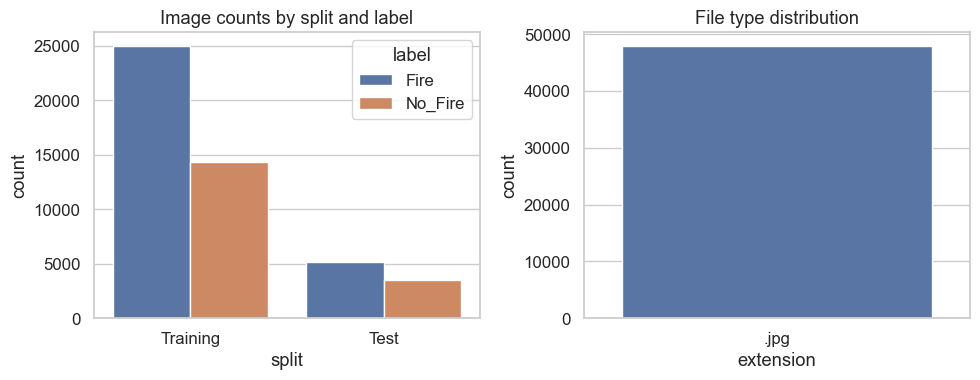

In [8]:
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
sns.countplot(data=df, x="split", hue="label")
plt.title("Image counts by split and label")

plt.subplot(1, 2, 2)
sns.countplot(data=df, x="extension")
plt.title("File type distribution")
plt.tight_layout()

plt.show()

## 7. Analyze Relationships and Correlations

With this dataset focusing on images and labels, we can look at relationships between splits, labels, and file types.

In [9]:
# Correlation matrix for available numeric features (if any)
numeric_df = df.select_dtypes(include=["number"])
if not numeric_df.empty:
    corr = numeric_df.corr()
    plt.figure(figsize=(6, 5))
    sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm")
    plt.title("Correlation matrix")
    plt.show()
else:
    print("No numeric columns available for correlation analysis. Consider adding numeric derived features (e.g., image dimensions).")

No numeric columns available for correlation analysis. Consider adding numeric derived features (e.g., image dimensions).


## 8. Export Cleaned Data or Results

Save the cleaned DataFrame for later use, such as training a model or further analysis.

In [10]:
output_path = Path("frames") / "frames_index.csv"
df.to_csv(output_path, index=False)
print("Exported cleaned dataset index to:", output_path)

Exported cleaned dataset index to: frames\frames_index.csv
